# Chapter 9 - Question 1 (page 395)

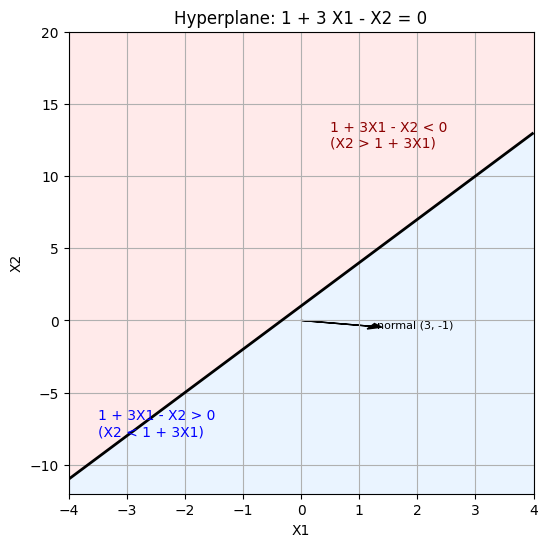

In [1]:
import numpy as np

import matplotlib.pyplot as plt

# define function and plotting grid
xx = np.linspace(-4, 4, 400)
yy = np.linspace(-12, 20, 400)
X, Y = np.meshgrid(xx, yy)
F = 1 + 3 * X - Y  # hyperplane: F = 0

plt.figure(figsize=(6,6))
# shade regions: F > 0 (below the line) and F < 0 (above the line)
plt.contourf(X, Y, F, levels=[-1e9, 0, 1e9], colors=['#ffdddd', '#ddeeff'], alpha=0.6)
# plot the hyperplane (line)
plt.contour(X, Y, F, levels=[0], colors='k', linewidths=2)
# annotate regions
plt.text(-3.5, -8, '1 + 3X1 - X2 > 0\n(X2 < 1 + 3X1)', color='blue')
plt.text(0.5, 12, '1 + 3X1 - X2 < 0\n(X2 > 1 + 3X1)', color='darkred')
# optional: show normal vector (coefficients (3, -1))
plt.arrow(0, 0, 1.2, -0.4, head_width=0.4, head_length=0.2, color='k')
plt.text(1.3, -0.5, 'normal (3, -1)', fontsize=8)

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Hyperplane: 1 + 3 X1 - X2 = 0')
plt.xlim(-4, 4)
plt.ylim(-12, 20)
plt.grid(True)
plt.show()

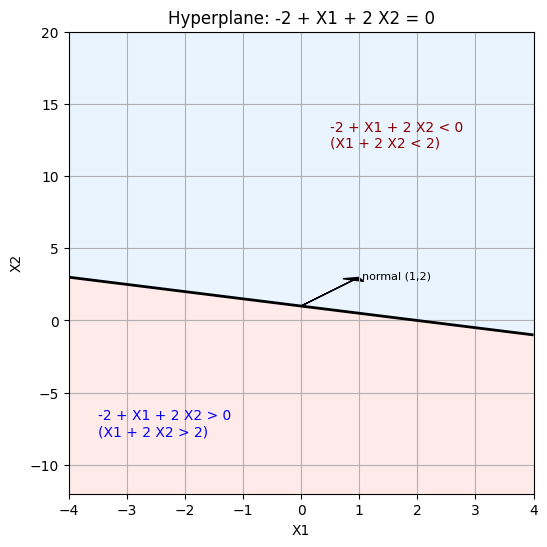

In [2]:
# sketch hyperplane: -2 + X1 + 2 X2 = 0 using existing X, Y
G = -2 + X + 2 * Y  # G == 0 is the hyperplane

plt.figure(figsize=(6,6))
# shade regions: G > 0 and G < 0
plt.contourf(X, Y, G, levels=[-1e9, 0, 1e9], colors=['#ffdddd', '#ddeeff'], alpha=0.6)
# plot the hyperplane
plt.contour(X, Y, G, levels=[0], colors='k', linewidths=2)

# annotate which side is which
plt.text(-3.5, -8, '-2 + X1 + 2 X2 > 0\n(X1 + 2 X2 > 2)', color='blue')
plt.text(0.5, 12, '-2 + X1 + 2 X2 < 0\n(X1 + 2 X2 < 2)', color='darkred')

# show normal vector (coefficients (1,2)) from a point on the line, e.g. (0,1)
plt.arrow(0, 1, 0.9, 1.8, head_width=0.4, head_length=0.2, color='k')
plt.text(1.05, 2.9, 'normal (1,2)', fontsize=8)

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Hyperplane: -2 + X1 + 2 X2 = 0')
plt.xlim(-4, 4)
plt.ylim(-12, 20)
plt.grid(True)
plt.show()

# Chapter 9 - Question 5

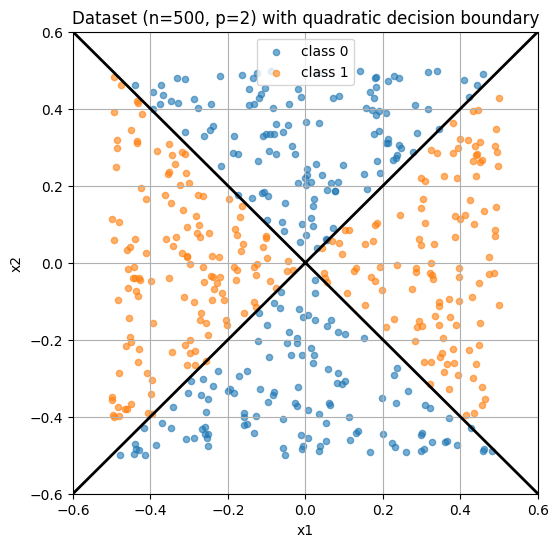

In [ ]:
# generate dataset with quadratic decision boundary
n = 500
p = 2
rng = np.random.default_rng(5)
x1 = rng.uniform(size=n) - 0.5
x2 = rng.uniform(size=n) - 0.5
X_data = np.column_stack((x1, x2))
y = (x1**2 - x2**2 > 0).astype(int)

# quick scatter plot with decision boundary x1^2 - x2^2 = 0
plt.figure(figsize=(6,6))
plt.scatter(X_data[y==0,0], X_data[y==0,1], s=20, color='C0', label='class 0', alpha=0.6)
plt.scatter(X_data[y==1,0], X_data[y==1,1], s=20, color='C1', label='class 1', alpha=0.6)

gx = np.linspace(-0.6, 0.6, 400)
gy = np.linspace(-0.6, 0.6, 400)
GX, GY = np.meshgrid(gx, gy)
H = GX**2 - GY**2
plt.contour(GX, GY, H, levels=[0], colors='k', linewidths=2)

# plot the observations
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Dataset (n=500, p=2) with quadratic decision boundary')
plt.legend()
plt.grid(True)
plt.show()

Intercept: [0.02220278]
Coefficients: [[-0.15143042  0.08184281]]
Training accuracy: 0.43


/Users/anhnguyen/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/anhnguyen/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/anhnguyen/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


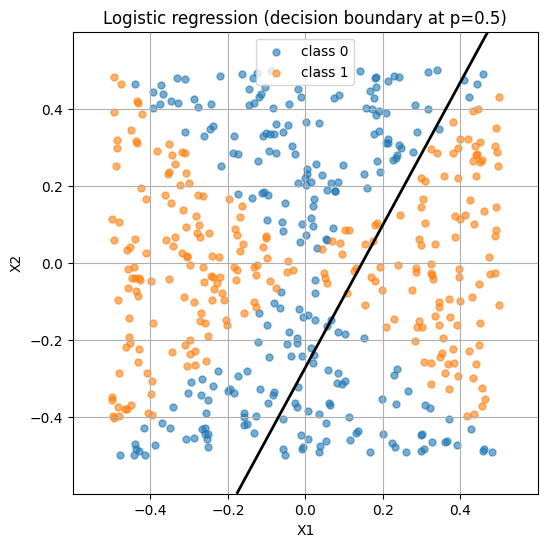

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Fit logistic regression using X1 and X2 as predictors.
# Uses existing variables in the notebook: prefer `x1` if present, else try `xx` as fallback.

# pick x1 from globals or fallback
if 'x1' in globals():
    x1_arr = x1
elif 'xx' in globals() and len(xx) == len(x2):
    x1_arr = xx
else:
    raise ValueError("No suitable X1 found in the notebook (no `x1` and `xx` length != `x2`).")

# assemble design matrix and fit
X = np.column_stack((x1_arr, x2))
clf = LogisticRegression(solver='lbfgs', max_iter=1000)
clf.fit(X, y)

# output results
print("Intercept:", clf.intercept_)
print("Coefficients:", clf.coef_)
y_pred = clf.predict(X)
print("Training accuracy:", accuracy_score(y, y_pred))

# optional: plot data and decision boundary
plt.figure(figsize=(6,6))
plt.scatter(X[y==0,0], X[y==0,1], s=25, alpha=0.6, label='class 0')
plt.scatter(X[y==1,0], X[y==1,1], s=25, alpha=0.6, label='class 1')

# decision boundary (probability = 0.5)
xxg = np.linspace(X[:,0].min()-0.1, X[:,0].max()+0.1, 200)
yyg = np.linspace(X[:,1].min()-0.1, X[:,1].max()+0.1, 200)
XXg, YYg = np.meshgrid(xxg, yyg)
grid = np.column_stack((XXg.ravel(), YYg.ravel()))
probs = clf.predict_proba(grid)[:,1].reshape(XXg.shape)
plt.contour(XXg, YYg, probs, levels=[0.5], colors='k', linewidths=2)

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Logistic regression (decision boundary at p=0.5)')
plt.legend()
plt.grid(True)
plt.show()

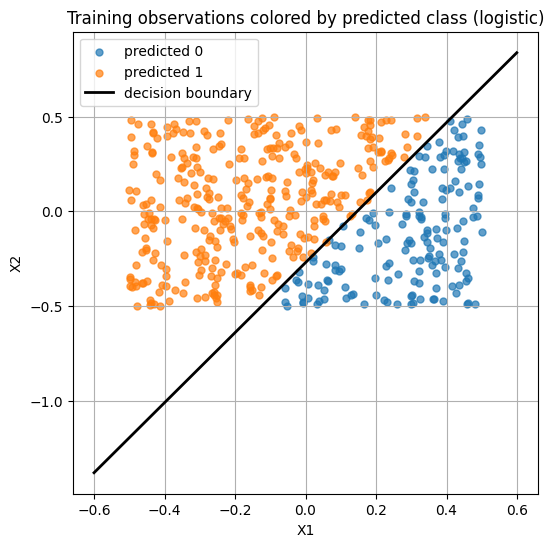

In [5]:
# apply model to training data and plot points colored by predicted label
y_pred_train = clf.predict(X)

plt.figure(figsize=(6,6))
plt.scatter(X[y_pred_train==0,0], X[y_pred_train==0,1], s=25, color='C0', alpha=0.7, label='predicted 0')
plt.scatter(X[y_pred_train==1,0], X[y_pred_train==1,1], s=25, color='C1', alpha=0.7, label='predicted 1')

# linear decision boundary from logistic coefficients: intercept + w1*x1 + w2*x2 = 0
w0 = clf.intercept_[0]
w1, w2 = clf.coef_[0]

xs = np.linspace(X[:,0].min()-0.1, X[:,0].max()+0.1, 200)
if abs(w2) < 1e-8:
    # nearly vertical boundary
    x_vert = -w0 / w1
    plt.axvline(x=x_vert, color='k', linewidth=2, label='decision boundary')
else:
    ys = -(w0 + w1 * xs) / w2
    plt.plot(xs, ys, 'k-', linewidth=2, label='decision boundary')

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Training observations colored by predicted class (logistic)')
plt.legend()
plt.grid(True)
plt.show()

Intercept: [0.00136738]
Coefficients:
  x1: -0.1859
  x2: -0.4994
  x1^2: 4.7661
  x2^2: -3.9469
  x1*x2: -0.0667
  log|x2|: -1.3559
  x1^3: -0.0348
  x2^3: 0.5928
Training accuracy: 0.972


/Users/anhnguyen/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/anhnguyen/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/anhnguyen/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/anhnguyen/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/anhnguyen/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_

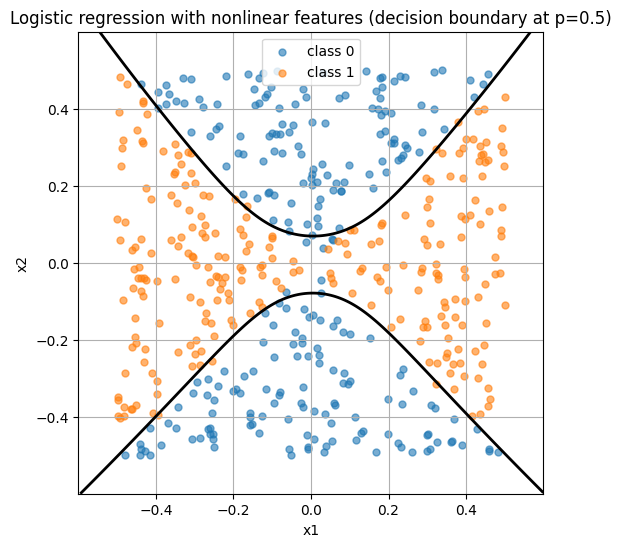

In [7]:
# fit logistic regression with nonlinear features (uses existing x1, x2, y, xxg, yyg, np, plt, LogisticRegression, accuracy_score)

eps = 1e-9

# construct nonlinear features
feat_dict = {
    'x1': x1,
    'x2': x2,
    'x1^2': x1**2,
    'x2^2': x2**2,
    'x1*x2': x1 * x2,
    'log|x2|': np.log(np.abs(x2) + eps),
    'x1^3': x1**3,
    'x2^3': x2**3
}

feat_names = list(feat_dict.keys())
X_nl = np.column_stack([feat_dict[n] for n in feat_names])

# standardize features (improves optimization)
mu = X_nl.mean(axis=0)
sigma = X_nl.std(axis=0)
sigma[sigma == 0] = 1.0
X_nl_std = (X_nl - mu) / sigma

# fit logistic regression
clf_nl = LogisticRegression(solver='lbfgs', max_iter=2000)
clf_nl.fit(X_nl_std, y)

# training performance and parameters
print("Intercept:", clf_nl.intercept_)
print("Coefficients:")
for n, c in zip(feat_names, clf_nl.coef_[0]):
    print(f"  {n}: {c:.4f}")
print("Training accuracy:", accuracy_score(y, clf_nl.predict(X_nl_std)))

# plot data and nonlinear decision boundary (probability = 0.5) on a grid using existing xxg, yyg
XXg, YYg = np.meshgrid(xxg, yyg)
grid_pts = np.column_stack((XXg.ravel(), YYg.ravel()))

# compute same nonlinear features for grid and standardize
grid_feat_list = [
    grid_pts[:,0],                      # x1
    grid_pts[:,1],                      # x2
    grid_pts[:,0]**2,                   # x1^2
    grid_pts[:,1]**2,                   # x2^2
    grid_pts[:,0]*grid_pts[:,1],        # x1*x2
    np.log(np.abs(grid_pts[:,1]) + eps),# log|x2|
    grid_pts[:,0]**3,                   # x1^3
    grid_pts[:,1]**3                    # x2^3
]
grid_X_nl = np.column_stack(grid_feat_list)
grid_X_nl_std = (grid_X_nl - mu) / sigma

probs = clf_nl.predict_proba(grid_X_nl_std)[:,1].reshape(XXg.shape)

plt.figure(figsize=(6,6))
plt.contour(XXg, YYg, probs, levels=[0.5], colors='k', linewidths=2)
plt.scatter(x1[y==0], x2[y==0], s=25, alpha=0.6, label='class 0')
plt.scatter(x1[y==1], x2[y==1], s=25, alpha=0.6, label='class 1')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Logistic regression with nonlinear features (decision boundary at p=0.5)')
plt.legend()
plt.grid(True)
plt.show()

Training accuracy (nonlinear): 0.972


/Users/anhnguyen/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/anhnguyen/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/anhnguyen/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


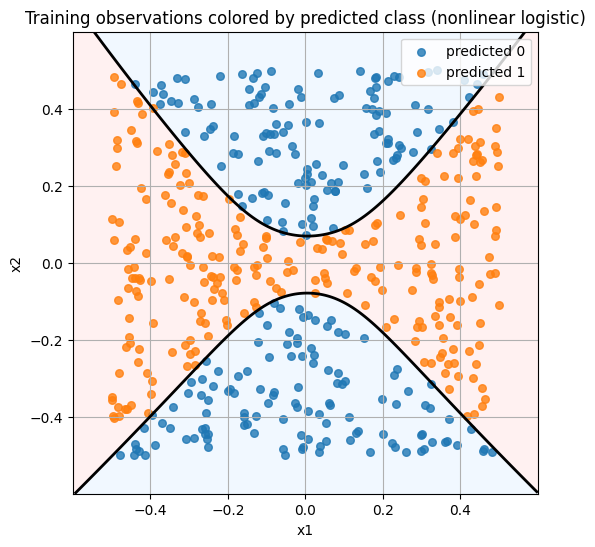

In [8]:
from sklearn.metrics import accuracy_score

# apply nonlinear logistic model to training data and plot predicted classes with nonlinear boundary

# predicted labels from nonlinear model
y_pred_nl = clf_nl.predict(X_nl_std)
print("Training accuracy (nonlinear):", accuracy_score(y, y_pred_nl))

plt.figure(figsize=(6,6))
# background shading of predicted probability and nonlinear decision boundary (p=0.5)
# recompute probs on grid if not already present
if 'probs' not in globals():
    XXg, YYg = np.meshgrid(xxg, yyg)
    grid_pts = np.column_stack((XXg.ravel(), YYg.ravel()))
    # build same nonlinear features as in cell 7
    eps = 1e-9
    grid_feat_list = [
        grid_pts[:,0],
        grid_pts[:,1],
        grid_pts[:,0]**2,
        grid_pts[:,1]**2,
        grid_pts[:,0]*grid_pts[:,1],
        np.log(np.abs(grid_pts[:,1]) + eps),
        grid_pts[:,0]**3,
        grid_pts[:,1]**3
    ]
    grid_X_nl = np.column_stack(grid_feat_list)
    grid_X_nl_std = (grid_X_nl - mu) / sigma
    probs = clf_nl.predict_proba(grid_X_nl_std)[:,1].reshape(XXg.shape)

plt.contourf(XXg, YYg, probs, levels=[0.0, 0.5, 1.0], colors=['#ddeeff', '#ffdddd'], alpha=0.4)
plt.contour(XXg, YYg, probs, levels=[0.5], colors='k', linewidths=2)

# scatter training points colored by predicted label
plt.scatter(x1[y_pred_nl==0], x2[y_pred_nl==0], s=30, color='C0', alpha=0.8, label='predicted 0')
plt.scatter(x1[y_pred_nl==1], x2[y_pred_nl==1], s=30, color='C1', alpha=0.8, label='predicted 1')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Training observations colored by predicted class (nonlinear logistic)')
plt.legend()
plt.grid(True)
plt.show()

Training accuracy (SVC, linear): 0.506


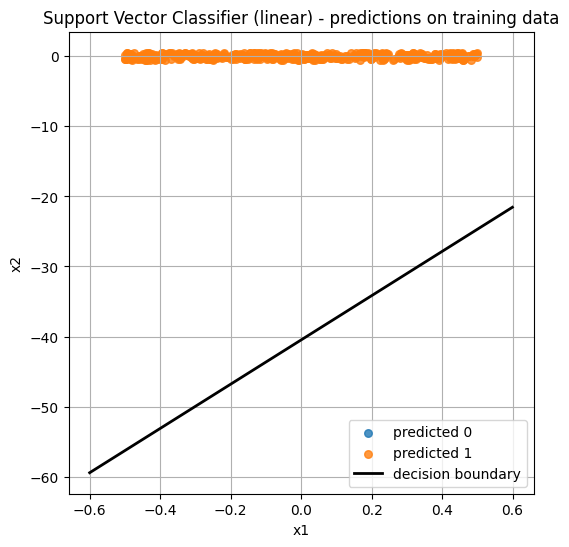

In [9]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# assemble predictor matrix and fit a linear support vector classifier
X_svc = np.column_stack((x1, x2))
svc = SVC(kernel='linear', C=1.0)
svc.fit(X_svc, y)

# predictions and training accuracy
y_pred_svc = svc.predict(X_svc)
print("Training accuracy (SVC, linear):", accuracy_score(y, y_pred_svc))

# plot training observations colored by predicted class
plt.figure(figsize=(6,6))
plt.scatter(X_svc[y_pred_svc==0,0], X_svc[y_pred_svc==0,1], s=30, color='C0', alpha=0.8, label='predicted 0')
plt.scatter(X_svc[y_pred_svc==1,0], X_svc[y_pred_svc==1,1], s=30, color='C1', alpha=0.8, label='predicted 1')

# linear decision boundary from SVC coefficients: w0 + w1*x1 + w2*x2 = 0
b = svc.intercept_[0]
w1, w2 = svc.coef_[0]

xs = np.linspace(X_svc[:,0].min()-0.1, X_svc[:,0].max()+0.1, 200)
if abs(w2) < 1e-8:
    x_vert = -b / w1
    plt.axvline(x=x_vert, color='k', linewidth=2, label='decision boundary')
else:
    ys = -(b + w1 * xs) / w2
    plt.plot(xs, ys, 'k-', linewidth=2, label='decision boundary')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Support Vector Classifier (linear) - predictions on training data')
plt.legend()
plt.grid(True)
plt.show()

Training accuracy (SVC, RBF): 0.986


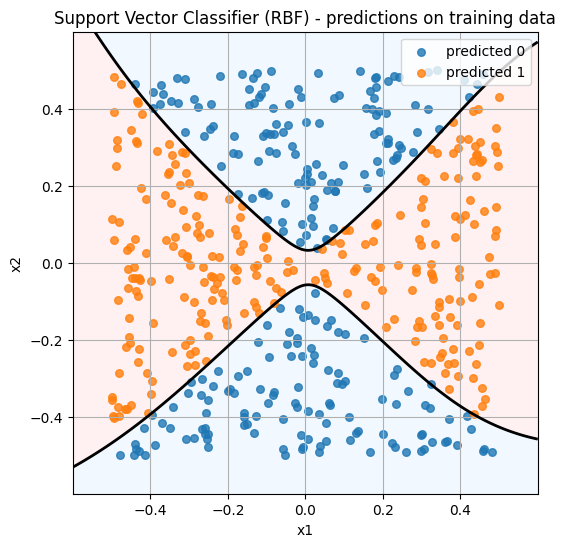

In [10]:
# Fit SVM with an RBF (nonlinear) kernel, predict training labels, and plot predicted classes + decision boundary

# assemble predictor matrix
X_nl = np.column_stack((x1, x2))

# fit nonlinear SVC (RBF)
svc_rbf = SVC(kernel='rbf', C=1.0)
svc_rbf.fit(X_nl, y)

# predictions on training data
y_pred_rbf = svc_rbf.predict(X_nl)
print("Training accuracy (SVC, RBF):", accuracy_score(y, y_pred_rbf))

# prepare grid for plotting decision function (use existing xxg, yyg)
XXg, YYg = np.meshgrid(xxg, yyg)
grid = np.column_stack((XXg.ravel(), YYg.ravel()))
df = svc_rbf.decision_function(grid).reshape(XXg.shape)

# plot
plt.figure(figsize=(6,6))
# background shading by sign of decision function
plt.contourf(XXg, YYg, df, levels=[df.min(), 0, df.max()], colors=['#ddeeff', '#ffdddd'], alpha=0.4)
# decision boundary (df = 0)
plt.contour(XXg, YYg, df, levels=[0], colors='k', linewidths=2)

# training points colored by predicted class
plt.scatter(X_nl[y_pred_rbf==0,0], X_nl[y_pred_rbf==0,1], s=30, color='C0', alpha=0.8, label='predicted 0')
plt.scatter(X_nl[y_pred_rbf==1,0], X_nl[y_pred_rbf==1,1], s=30, color='C1', alpha=0.8, label='predicted 1')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Support Vector Classifier (RBF) - predictions on training data')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
from sklearn.metrics import accuracy_score, confusion_matrix

# compute accuracies
acc_logistic = accuracy_score(y, y_pred_train)
acc_logistic_nl = accuracy_score(y, y_pred_nl)
acc_svc_linear = accuracy_score(y, y_pred_svc)
acc_svc_rbf = accuracy_score(y, y_pred_rbf)

# confusion matrices
cm_logistic = confusion_matrix(y, y_pred_train)
cm_logistic_nl = confusion_matrix(y, y_pred_nl)
cm_svc_linear = confusion_matrix(y, y_pred_svc)
cm_svc_rbf = confusion_matrix(y, y_pred_rbf)

print("Summary of training performance (higher is better):")
print(f"  Linear logistic accuracy     : {acc_logistic:.3f}")
print(f"  Nonlinear logistic accuracy  : {acc_logistic_nl:.3f}")
print(f"  Linear SVC accuracy         : {acc_svc_linear:.3f}")
print(f"  RBF SVC accuracy            : {acc_svc_rbf:.3f}")
print()

print("Confusion matrices (rows=true class 0/1, cols=predicted 0/1):")
print("  Linear logistic:\n", cm_logistic)
print("  Nonlinear logistic:\n", cm_logistic_nl)
print("  Linear SVC:\n", cm_svc_linear)
print("  RBF SVC:\n", cm_svc_rbf)
print()

# short, data-driven comments
print("Comments:")
if (y_pred_svc == 1).all():
    print(" - Linear SVC predicted a single class (all 1s) -> failed to separate classes (degenerate solution).")
else:
    print(" - Linear SVC produces a linear boundary; inspect its confusion matrix for class-specific errors.")

print(f" - Linear logistic is limited by a linear boundary (accuracy {acc_logistic:.3f}); it cannot model the quadratic decision surface in the data.")
print(f" - Nonlinear logistic (engineered features) improves performance (accuracy {acc_logistic_nl:.3f}) by capturing the curved boundary.")
print(f" - RBF SVC achieves similar/better performance (accuracy {acc_svc_rbf:.3f}) by using a nonlinear kernel to separate classes in feature space.")
print()


Summary of training performance (higher is better):
  Linear logistic accuracy     : 0.430
  Nonlinear logistic accuracy  : 0.972
  Linear SVC accuracy         : 0.506
  RBF SVC accuracy            : 0.986

Confusion matrices (rows=true class 0/1, cols=predicted 0/1):
  Linear logistic:
 [[ 63 184]
 [101 152]]
  Nonlinear logistic:
 [[239   8]
 [  6 247]]
  Linear SVC:
 [[  0 247]
 [  0 253]]
  RBF SVC:
 [[243   4]
 [  3 250]]

Comments:
 - Linear SVC predicted a single class (all 1s) -> failed to separate classes (degenerate solution).
 - Linear logistic is limited by a linear boundary (accuracy 0.430); it cannot model the quadratic decision surface in the data.
 - Nonlinear logistic (engineered features) improves performance (accuracy 0.972) by capturing the curved boundary.
 - RBF SVC achieves similar/better performance (accuracy 0.986) by using a nonlinear kernel to separate classes in feature space.



# Chapter 10 - Question 2 (page 465)


## Softmax Definition
The softmax probability for class m is:

p_m = exp(z_m) / (sum over all classes of exp(z_l))

---

## (a) Adding a constant c to every z_l

Suppose we create new logits:

z'_l = z_l + c

Then the new softmax probability becomes:

p'_m = exp(z_m + c) / (sum_l exp(z_l + c))

Factor out exp(c) from numerator and denominator:

p'_m = (exp(c) * exp(z_m)) / (exp(c) * sum_l exp(z_l))

Since exp(c) cancels out:

p'_m = exp(z_m) / sum_l exp(z_l) = p_m

**Conclusion:** Adding the same constant to every logit does not change the softmax probabilities.

---

## (b) Adding constants to the coefficients in the multinomial logistic model

The linear predictor for class k is:

z_k = β_k0 + β_k1 * x1 + ... + β_kp * xp

Now suppose we add constants c0, c1, ..., cp to each coefficient across all classes:

β'_kj = β_kj + c_j

The new predictor becomes:

z'_k = (β_k0 + c0) + (β_k1 + c1) * x1 + ... + (β_kp + cp) * xp

Group the terms:

z'_k = (β_k0 + β_k1 * x1 + ... + β_kp * xp)
       + (c0 + c1 * x1 + ... + cp * xp)

The first part is just z_k.  
The second part is the same for every class k at a given input x.

Call this common shift:

d(x) = c0 + c1 * x1 + ... + cp * xp

Thus:

z'_k = z_k + d(x)

Since every class gets the same shift d(x), part (a) tells us the softmax probabilities remain unchanged.

**Conclusion:** Adding the same set of offsets to each class's coefficients produces identical predictions.

---

## Final Insight

These two results show that the softmax model is over-parametrized. In practice, regularization and SGD prevent this from causing problems.
